<a href="https://colab.research.google.com/github/minhmax098/Brain-Tumor-CNN/blob/main/AI_Powered_Brain_Tumor_Detection_Binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Powered Brain Tumor Detection using Deep Learning

Binary MRI brain tumor detection notebook.

**Binary labels:**
- `0 = No Tumor`
- `1 = Tumor` (`glioma`, `meningioma`, and `pituitary` are merged into one class)

Pipeline: DataLoader → preprocessing → MobileNetV2 transfer learning → training → evaluation → confidence score → optional Streamlit app.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Step 0: Imports
# If needed in Colab: !pip install kagglehub streamlit -q

import os, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## Step 1: Dataset path

Expected structure:

```text
Brain_Tumor_Project/
├── Training/
│   ├── glioma/
│   ├── meningioma/
│   ├── pituitary/
│   └── notumor/
└── Testing/
    ├── glioma/
    ├── meningioma/
    ├── pituitary/
    └── notumor/
```

Change `DATASET_ROOT` to your own path in Colab or Google Drive.

In [3]:
# Step 1: Set dataset path

from pathlib import Path

DATASET_ROOT = Path('/content/drive/MyDrive/Brain_Tumor_Project/dataset')

TRAIN_DIR = DATASET_ROOT / 'Training'
TEST_DIR  = DATASET_ROOT / 'Testing'

print('Dataset root:', DATASET_ROOT)
print('Train exists:', TRAIN_DIR.exists(), TRAIN_DIR)
print('Test exists:', TEST_DIR.exists(), TEST_DIR)

Dataset root: /content/drive/MyDrive/Brain_Tumor_Project/dataset
Train exists: True /content/drive/MyDrive/Brain_Tumor_Project/dataset/Training
Test exists: True /content/drive/MyDrive/Brain_Tumor_Project/dataset/Testing


In [ ]:
# Optional: Download from KaggleHub
# Uncomment if you need to download the dataset.

# import kagglehub
# downloaded_path = kagglehub.dataset_download('sartajbhuvaji/brain-tumor-classification-mri')
# print('Downloaded path:', downloaded_path)
# DATASET_ROOT = Path(downloaded_path)
# TRAIN_DIR = DATASET_ROOT / 'Training'
# TEST_DIR = DATASET_ROOT / 'Testing'

## Step 2: Binary dataset class

For this topic, the original four-class dataset is converted into a binary detection task:

- `notumor` → `No Tumor` = 0
- `glioma`, `meningioma`, `pituitary` → `Tumor` = 1

In [4]:
# Step 2: Dataset class

IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
NO_TUMOR_NAMES = {'notumor', 'no_tumor', 'no tumor', 'no-tumor', 'normal', 'non_tumor', 'nontumor'}
class_names = ['No Tumor', 'Tumor']

class BrainTumorBinaryDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []
        if not self.root_dir.exists():
            raise FileNotFoundError(f'Dataset folder not found: {self.root_dir}')
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            class_name = class_folder.name.lower().strip()
            label = 0 if class_name in NO_TUMOR_NAMES else 1
            for img_path in class_folder.rglob('*'):
                if img_path.suffix.lower() in IMG_EXTENSIONS:
                    self.samples.append((str(img_path), label, class_folder.name))
        if not self.samples:
            raise ValueError(f'No images found in {self.root_dir}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, _ = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

    def get_label_distribution(self):
        return Counter([label for _, label, _ in self.samples])

    def get_original_class_distribution(self):
        return Counter([original_class for _, _, original_class in self.samples])

## Step 3: Preprocessing and DataLoader

The images are resized to `224×224`, augmented during training, and normalized using ImageNet statistics because the model uses pretrained MobileNetV2 weights.

In [5]:
# Step 3: Transforms and DataLoaders

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = BrainTumorBinaryDataset(TRAIN_DIR, transform=train_transform)
test_dataset = BrainTumorBinaryDataset(TEST_DIR, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                          pin_memory=True if device.type == 'cuda' else False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                         pin_memory=True if device.type == 'cuda' else False)

print('Original training distribution:', train_dataset.get_original_class_distribution())
print('Binary training distribution:', {class_names[k]: v for k, v in train_dataset.get_label_distribution().items()})
print('Original testing distribution:', test_dataset.get_original_class_distribution())
print('Binary testing distribution:', {class_names[k]: v for k, v in test_dataset.get_label_distribution().items()})
print('Training images:', len(train_dataset), '| Testing images:', len(test_dataset))
print('Training batches:', len(train_loader), '| Testing batches:', len(test_loader))

Original training distribution: Counter({'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400})
Binary training distribution: {'Tumor': 4200, 'No Tumor': 1400}
Original testing distribution: Counter({'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400})
Binary testing distribution: {'Tumor': 1200, 'No Tumor': 400}
Training images: 5600 | Testing images: 1600
Training batches: 175 | Testing batches: 50


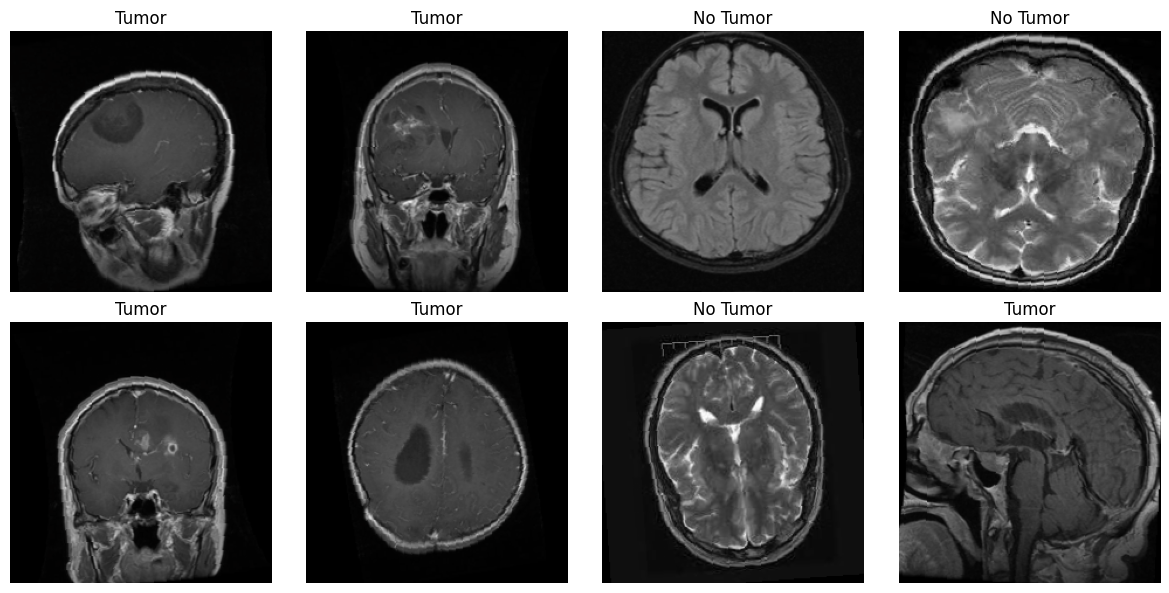

In [6]:
# Step 4: Visualize samples

def inverse_normalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor.cpu() * std + mean

images, labels = next(iter(train_loader))
plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    img = inverse_normalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(class_names[labels[i].item()])
    plt.axis('off')
plt.tight_layout()
plt.show()

## Step 5: MobileNetV2 model

The final layer is changed to output two classes: `No Tumor` and `Tumor`.

In [7]:
# Step 5: Build MobileNetV2

def build_mobilenetv2(num_classes=2, freeze_backbone=True):
    weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
    model = models.mobilenet_v2(weights=weights)
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(128, num_classes)
    )
    return model

model = build_mobilenetv2(num_classes=2, freeze_backbone=True).to(device)
print(model.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 91.0MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=128, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=2, bias=True)
)


In [8]:
# Step 6: Training utilities

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=2)

EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
MODEL_PATH = 'best_brain_tumor_detection_mobilenetv2.pth'


def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def evaluate_loss_acc(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

## Step 6: Train classification head

In [9]:
# Step 7: Train Stage 1

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate_loss_acc(model, test_loader)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_PATH)
        print('Best model saved.')
    else:
        patience_counter += 1
        print(f'EarlyStopping counter: {patience_counter}/{EARLY_STOPPING_PATIENCE}')

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print('Early stopping triggered.')
        break

Epoch [01/30] | Train Loss: 0.2789 | Train Acc: 0.8893 | Val Loss: 0.1495 | Val Acc: 0.9481
Best model saved.
Epoch [02/30] | Train Loss: 0.1348 | Train Acc: 0.9537 | Val Loss: 0.1817 | Val Acc: 0.9375
EarlyStopping counter: 1/5
Epoch [03/30] | Train Loss: 0.1139 | Train Acc: 0.9593 | Val Loss: 0.1649 | Val Acc: 0.9450
EarlyStopping counter: 2/5
Epoch [04/30] | Train Loss: 0.1016 | Train Acc: 0.9621 | Val Loss: 0.1520 | Val Acc: 0.9487
EarlyStopping counter: 3/5
Epoch [05/30] | Train Loss: 0.1022 | Train Acc: 0.9623 | Val Loss: 0.1451 | Val Acc: 0.9500
Best model saved.
Epoch [06/30] | Train Loss: 0.0969 | Train Acc: 0.9668 | Val Loss: 0.1533 | Val Acc: 0.9500
EarlyStopping counter: 1/5
Epoch [07/30] | Train Loss: 0.0908 | Train Acc: 0.9698 | Val Loss: 0.1440 | Val Acc: 0.9513
Best model saved.
Epoch [08/30] | Train Loss: 0.0970 | Train Acc: 0.9661 | Val Loss: 0.1413 | Val Acc: 0.9531
Best model saved.
Epoch [09/30] | Train Loss: 0.0933 | Train Acc: 0.9659 | Val Loss: 0.1543 | Val Acc:

## Optional Step 7: Fine-tuning

This unfreezes the last four MobileNetV2 feature blocks and trains them with a smaller learning rate.

In [10]:
# Step 8: Fine-tuning

DO_FINE_TUNING = True
FINE_TUNE_EPOCHS = 10

if DO_FINE_TUNING:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    for param in model.features[-4:].parameters():
        param.requires_grad = True

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=2)

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(FINE_TUNE_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader)
        val_loss, val_acc = evaluate_loss_acc(model, test_loader)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Fine-tune [{epoch+1:02d}/{FINE_TUNE_EPOCHS}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), MODEL_PATH)
            print('Best fine-tuned model saved.')
        else:
            patience_counter += 1

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print('Fine-tuning early stopping triggered.')
            break

Fine-tune [01/10] | Train Loss: 0.0791 | Train Acc: 0.9732 | Val Loss: 0.1377 | Val Acc: 0.9537
Best fine-tuned model saved.
Fine-tune [02/10] | Train Loss: 0.0643 | Train Acc: 0.9761 | Val Loss: 0.0970 | Val Acc: 0.9650
Best fine-tuned model saved.
Fine-tune [03/10] | Train Loss: 0.0555 | Train Acc: 0.9812 | Val Loss: 0.1151 | Val Acc: 0.9606
Fine-tune [04/10] | Train Loss: 0.0459 | Train Acc: 0.9850 | Val Loss: 0.0899 | Val Acc: 0.9656
Best fine-tuned model saved.
Fine-tune [05/10] | Train Loss: 0.0458 | Train Acc: 0.9836 | Val Loss: 0.0814 | Val Acc: 0.9706
Best fine-tuned model saved.
Fine-tune [06/10] | Train Loss: 0.0408 | Train Acc: 0.9852 | Val Loss: 0.0719 | Val Acc: 0.9756
Best fine-tuned model saved.
Fine-tune [07/10] | Train Loss: 0.0390 | Train Acc: 0.9868 | Val Loss: 0.0706 | Val Acc: 0.9744
Best fine-tuned model saved.
Fine-tune [08/10] | Train Loss: 0.0321 | Train Acc: 0.9898 | Val Loss: 0.0681 | Val Acc: 0.9762
Best fine-tuned model saved.
Fine-tune [09/10] | Train Los

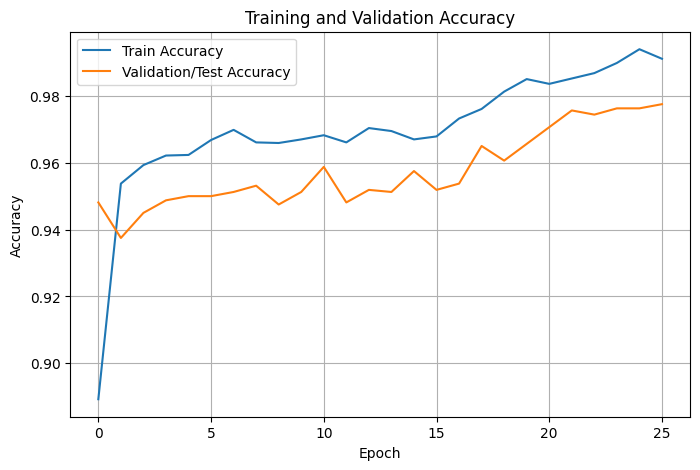

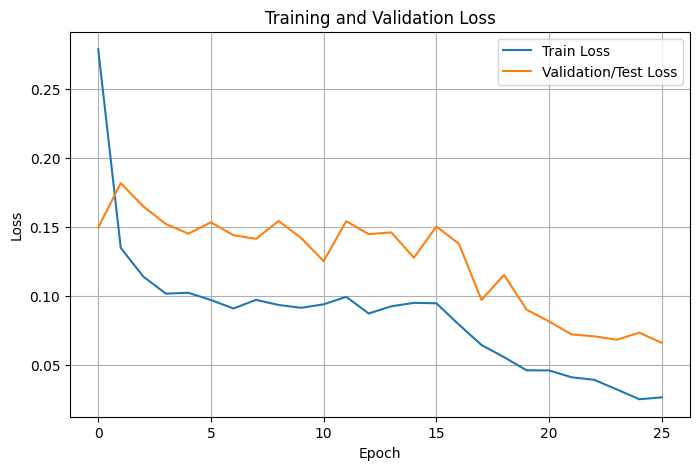

In [11]:
# Step 9: Training curves

plt.figure(figsize=(8, 5))
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation/Test Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Training and Validation Accuracy')
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation/Test Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training and Validation Loss')
plt.legend(); plt.grid(True); plt.show()

## Step 8: Final evaluation

Metrics: Accuracy, Precision, Recall/Sensitivity, F1-score, Specificity, and AUC.

In [12]:
# Step 10: Final evaluation

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_labels, all_preds, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

results = {
    'Accuracy': accuracy_score(all_labels, all_preds),
    'Precision': precision_score(all_labels, all_preds, zero_division=0),
    'Recall/Sensitivity': recall_score(all_labels, all_preds, zero_division=0),
    'F1-score': f1_score(all_labels, all_preds, zero_division=0),
    'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
    'AUC': roc_auc_score(all_labels, all_probs)
}

for k, v in results.items():
    print(f'{k}: {v:.4f}')

print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

Accuracy: 0.9775
Precision: 0.9991
Recall/Sensitivity: 0.9708
F1-score: 0.9848
Specificity: 0.9975
AUC: 0.9989

Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.92      1.00      0.96       400
       Tumor       1.00      0.97      0.98      1200

    accuracy                           0.98      1600
   macro avg       0.96      0.98      0.97      1600
weighted avg       0.98      0.98      0.98      1600



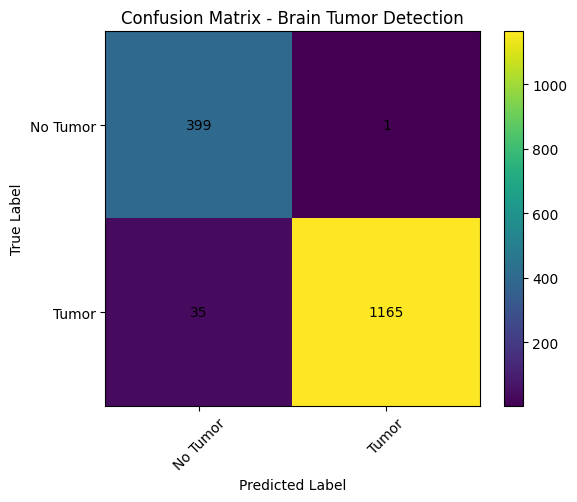

In [13]:
# Step 11: Confusion matrix

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix - Brain Tumor Detection')
plt.colorbar()
plt.xticks(np.arange(2), class_names, rotation=45)
plt.yticks(np.arange(2), class_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

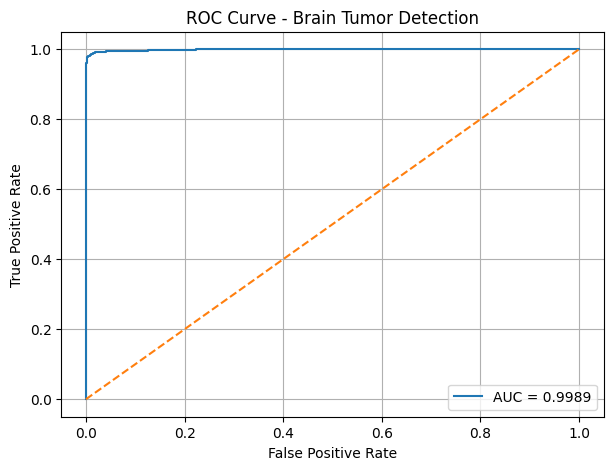

In [14]:
# Step 12: ROC curve

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
auc = results['AUC']
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Brain Tumor Detection')
plt.legend(); plt.grid(True); plt.show()

## Step 9: Confidence threshold analysis

This supports the idea of reporting high-certainty predictions when confidence is above `80%`.

In [15]:
# Step 13: Confidence threshold analysis

max_confidence = np.maximum(all_probs, 1 - all_probs)
correct_predictions = (all_preds == all_labels)
rows = []
for threshold in [0.50, 0.60, 0.70, 0.80, 0.90]:
    selected = max_confidence >= threshold
    rows.append({
        'Confidence Threshold': threshold,
        'Selected Cases': int(selected.sum()),
        'Coverage': round(float(selected.mean()), 4),
        'Accuracy on Selected Cases': round(float(correct_predictions[selected].mean()), 4) if selected.sum() > 0 else None
    })
threshold_df = pd.DataFrame(rows)
threshold_df

,Confidence Threshold,Selected Cases,Coverage,Accuracy on Selected Cases
0,0.5,1600,1.0000,0.9775
1,0.6,1592,0.9950,0.9805
2,0.7,1573,0.9831,0.9828
3,0.8,1557,0.9731,0.9839
4,0.9,1523,0.9519,0.9921


In [16]:
# Step 14: Single image prediction function

def predict_single_image(image_path, model, transform=test_transform, threshold=0.80):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)[0]
        confidence, pred_idx = torch.max(probabilities, dim=0)
    prediction = class_names[pred_idx.item()]
    confidence_score = float(confidence.item())
    certainty = 'High-confidence prediction' if confidence_score >= threshold else 'Uncertain prediction - expert review recommended'
    return {
        'prediction': prediction,
        'confidence_percent': round(confidence_score * 100, 2),
        'certainty': certainty
    }

# Example:
# predict_single_image('/content/example_mri.jpg', model)

## Optional Step 10: Generate Streamlit app

This creates an `app.py` file. Put `app.py` and the saved `.pth` model in the same folder, then run:

```bash
streamlit run app.py
```

In [17]:
# Step 15: Create app.py for Streamlit demo

app_code = """
import streamlit as st
from PIL import Image
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models

CLASS_NAMES = ['No Tumor', 'Tumor']
MODEL_PATH = 'best_brain_tumor_detection_mobilenetv2.pth'

@st.cache_resource
def load_model():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
    model = models.mobilenet_v2(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(128, 2)
    )
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    return model, device

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

st.set_page_config(page_title='AI-Powered Brain Tumor Detection', layout='centered')
st.title('AI-Powered Brain Tumor Detection using Deep Learning')
st.write('Upload a brain MRI image to predict whether a tumor is present or absent.')

uploaded_file = st.file_uploader('Upload MRI image', type=['jpg', 'jpeg', 'png'])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption='Uploaded MRI Image', use_column_width=True)
    model, device = load_model()
    input_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)[0]
        confidence, pred_idx = torch.max(probabilities, dim=0)
    prediction = CLASS_NAMES[pred_idx.item()]
    confidence_score = confidence.item() * 100
    st.subheader('Prediction Result')
    st.write(f'**Prediction:** {prediction}')
    st.write(f'**Confidence Score:** {confidence_score:.2f}%')
    if confidence_score >= 80:
        st.success('High-confidence prediction')
    else:
        st.warning('Uncertain prediction. Expert medical review is recommended.')
    st.info('Disclaimer: This system is for educational decision-support demonstration only. Final diagnosis must be made by qualified medical professionals.')
"""

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print('app.py created successfully.')

app.py created successfully.


## Short explanation for report / presentation

> The original MRI dataset contains four classes: glioma, meningioma, pituitary tumor, and no tumor. Since this project focuses on brain tumor detection rather than tumor type classification, all tumor classes were merged into a single Tumor class, while the no tumor class was kept as No Tumor. Therefore, the task was formulated as a binary classification problem. A pretrained MobileNetV2 CNN was used as the backbone model. MRI images were resized to 224×224 pixels, normalized, and augmented during training. The final classification layer was modified to output two classes. The system predicts whether a tumor is present or absent and provides a confidence score to support decision-making.